### Phase 5: Evaluation & Vergleich (Der Kern der Thesis)
Beweis des Mehrwerts zur Reduktion des **Sequence of Returns Risk**.
*   **Metriken:**
    *   **Maximum Drawdown (MDD):** Wie tief war der maximale Fall? (Wichtigstes Ziel).
    *   **Sharpe Ratio / Sortino Ratio:** Risiko-adjustierte Rendite.
    *   **Calmar Ratio:** Rendite im Verhältnis zum Drawdown.
    *   **Regime-Stabilität:** Wie oft schaltet das Modell um? (LSTMs neigen zum "Overfitting" und Rauschen).

In [1]:
import pandas as pd

# Daten aus dem data-Ordner laden
backtesting_results = pd.read_parquet("../data/04_backtesting_results_data.parquet")
backtesting_transaction_costs = pd.read_parquet("../data/04_backtesting_transaction_costs_data.parquet")
test_df = pd.read_parquet("../data/03_test_df_data.parquet")

In [2]:
import numpy as np

# 1. Daten aus dem data-Ordner laden
test_df = pd.read_parquet("../data/03_test_df_data.parquet")
backtesting_results = pd.read_parquet("../data/04_backtesting_results_data.parquet")

# 2. Funktion zur Evaluation
def evaluate_strategies(results_df, trades_df, costs_df):
    stats = []
    
    for col in results_df.columns:
        equity_curve = results_df[col]
        daily_returns = equity_curve.pct_change().dropna()
        
        # 1. Total Return & CAGR (Annualisierte Rendite)
        total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
        days = (equity_curve.index[-1] - equity_curve.index[0]).days
        cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0])**(365.25/days) - 1
        
        # 2. Volatilität (annualisiert)
        vol = daily_returns.std() * np.sqrt(252)
        
        # 3. Sharpe Ratio (Annahme: Risk-Free Rate = 0, da Cash bereits in der Strategie (im Portfolio) steckt)
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 else 0
        
        # 4. Maximum Drawdown
        peak = equity_curve.expanding(min_periods=1).max()
        drawdown = (equity_curve / peak) - 1
        mdd = drawdown.min()
        
        # 5. Sortino Ratio (Fokus auf Downside-Risiko)
        downside_returns = daily_returns[daily_returns < 0]
        downside_std = downside_returns.std() * np.sqrt(252)
        sortino = (daily_returns.mean() * 252) / downside_std if downside_std != 0 else np.nan
        
        # 6. Calmar Ratio (Verhältnis Rendite zu Max Drawdown)
        calmar = cagr / abs(mdd) if mdd != 0 else np.nan
        
        # 7. Anzahl der Trades (Regime-Wechsel)
        # Wir messen, wie oft das Modell von 0 auf 1 oder umgekehrt springt
        if col in trades_df.columns:
            # Signaländerungen zählen (Absolutwert der Differenz)
            switches = trades_df[col].diff().abs().sum()
        else:
            switches = 0 # Buy & Hold hat 0 Wechsel
        
        # 8. Gesamte Transaktionskosten am Ende des Zeitraums extrahieren
        if col in costs_df.columns:
            total_fees = costs_df[col].iloc[-1]
        else:
            total_fees = 0.0
            
        stats.append({
            'Strategie': col.replace('_', ' '),
            'Total Return': f"{total_return:.2%}",
            'CAGR (p.a.)': f"{cagr:.2%}",
            'Volatilität': f"{vol:.2%}",
            'Max Drawdown': f"{mdd:.2%}",
            'Sharpe Ratio': round(sharpe, 2),
            'Sortino Ratio': round(sortino, 2),
            'Calmar Ratio': round(calmar, 2),
            'Regime-Wechsel': int(switches),
            'Gesamtkosten (Gebühren)': f"{total_fees:.2%}"
        })
    
    return pd.DataFrame(stats).set_index('Strategie')

# --- 3. DYNAMISCHE ZUORDNUNG DER SIGNALE ---

# Wir erstellen automatisch ein DataFrame, das die Signale so benennt wie die Strategien
signals_to_count = pd.DataFrame(index=test_df.index)

# Wir suchen im test_df nach allen Spalten, die auf _Signal enden
signal_columns = [c for c in test_df.columns if c.endswith('_Signal')]

for sig_col in signal_columns:
    # Extrahiere Modellnamen (z.B. 'LSTM' aus 'LSTM_Signal')
    model_name = sig_col.rsplit('_', 1)[0]
    # Mappe das Signal auf den Modellnamen für die evaluate-Funktion
    signals_to_count[model_name] = test_df[sig_col]

# 4. Evaluation ausführen
evaluation_table = evaluate_strategies(backtesting_results, signals_to_count, backtesting_transaction_costs)

# 5. Anzeige und Persistierung
print("\n--- UMFASSENDE EVALUATION (DYNAMISCH) ---")
display(evaluation_table)

# Tabelle in eine Markdown-Dateie schreiben
evaluation_table.to_markdown('../assets/evaluation_table.md', index=True)
print("\nEvaluationstabelle erfolgreich unter ../assets/evaluation_table.md persistiert.")

#--- Wir erhalten in diesem Schritt neben df und test_df sowie backtesting_results trades_df mit binären Handelssignalen ---


--- UMFASSENDE EVALUATION (DYNAMISCH) ---


,Total Return,CAGR (p.a.),Volatilität,Max Drawdown,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Regime-Wechsel,Gesamtkosten (Gebühren)
Strategie,,,,,,,,,
Buy Hold,89.77%,9.54%,12.61%,-27.10%,0.79,1.02,0.35,0,0.00%
HMM,71.78%,8.00%,4.96%,-6.79%,1.58,1.47,1.18,29,2.90%
MS Univariate,150.69%,13.96%,6.33%,-6.25%,2.10,2.73,2.23,42,4.20%
MS Exo,148.40%,13.81%,6.42%,-5.44%,2.05,2.65,2.54,38,3.80%
LSTM,58.33%,6.75%,8.04%,-19.21%,0.86,1.02,0.35,56,5.60%
LSTM Unsupervised,54.46%,6.38%,8.16%,-13.68%,0.80,0.83,0.47,25,2.60%



Evaluationstabelle erfolgreich unter ../assets/evaluation_table.md persistiert.


Starte Monte Carlo Simulation für Szenario: Standard


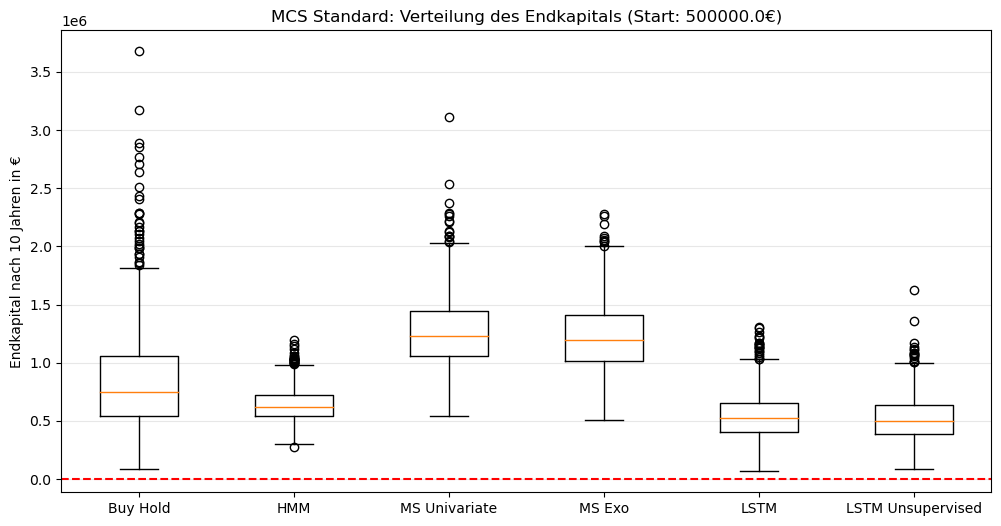

Starte Monte Carlo Simulation für Szenario: Aggressive


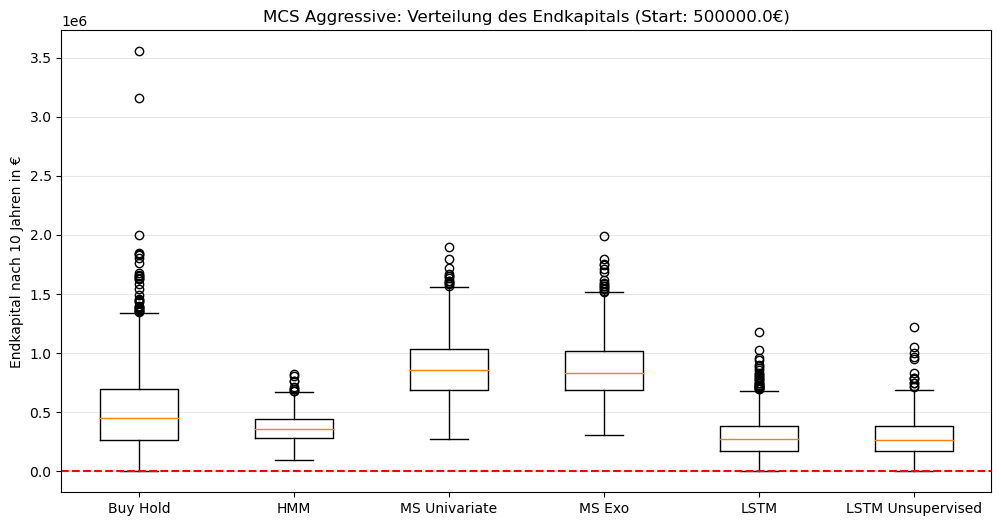

Starte Monte Carlo Simulation für Szenario: Low_Capital


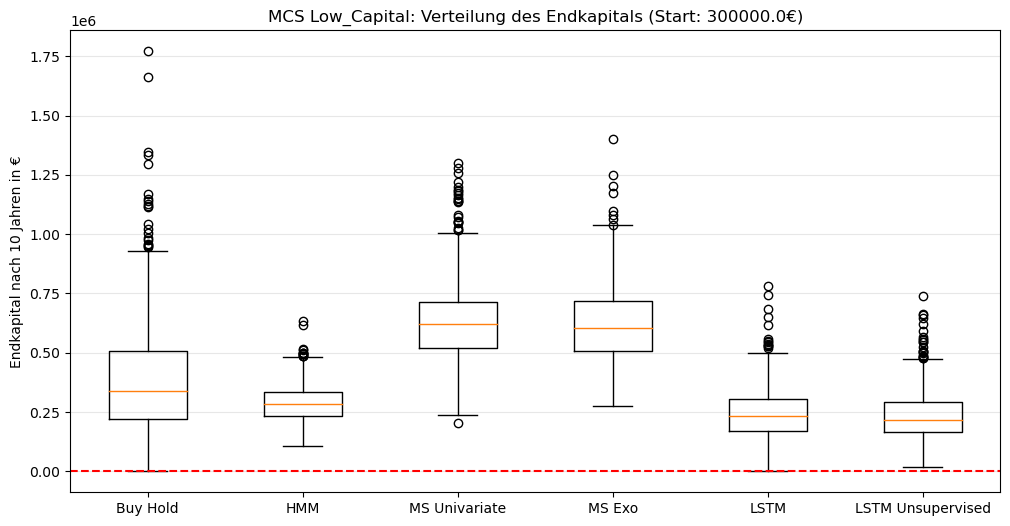

Ruin-Wahrscheinlichkeit Median Endkapital
Szenario    Strategie                                                  
Standard    Buy Hold                            0.00%      746,397.52 €
            HMM                                 0.00%      621,160.56 €
            MS Univariate                       0.00%    1,232,297.50 €
            MS Exo                              0.00%    1,191,794.59 €
            LSTM                                0.00%      524,424.66 €
            LSTM Unsupervised                   0.00%      499,224.41 €
Aggressive  Buy Hold                            1.60%      453,140.46 €
            HMM                                 0.00%      355,301.78 €
            MS Univariate                       0.00%      859,548.31 €
            MS Exo                              0.00%      829,707.45 €
            LSTM                                0.90%      271,166.30 €
            LSTM Unsupervised                   0.70%      263,999.00 €
Low_Capital Buy Hold                            0.20%      336,927.62 €
            HMM                                 0.00%      282,740.23 €
            MS Univariate                       0.00%      620,279.47 €
            MS Exo                              0.00%      605,094.65 €
            LSTM                                0.00%      233,726.90 €
            LSTM Unsupervised                   0.00%      217,507.84 €

Alle Monte Carlo Simulationen abgeschlossen.


      Standard_Buy_Hold_path_000  Standard_Buy_Hold_path_001  \
0                  498870.947400               497661.806038   
1                  498469.210087               502260.242256   
2                  500199.393317               501173.545197   
3                  500407.007948               499557.489453   
4                  503568.830494               500239.728103   
...                          ...                         ...   
2515               990727.022057               618477.833994   
2516               991757.974653               619547.473360   
2517               989546.294252               618091.559335   
2518               979179.192865               614438.635379   
2519               983165.282860               612880.854063   

      Standard_Buy_Hold_path_002  Standard_Buy_Hold_path_003  \
0                  496205.163471                4.937167e+05   
1                  496768.059181                4.924205e+05   
2                  495711.610961       

Plotte Pfad-Verläufe für Aggressive...


Plotte Pfad-Verläufe für Low_Capital...


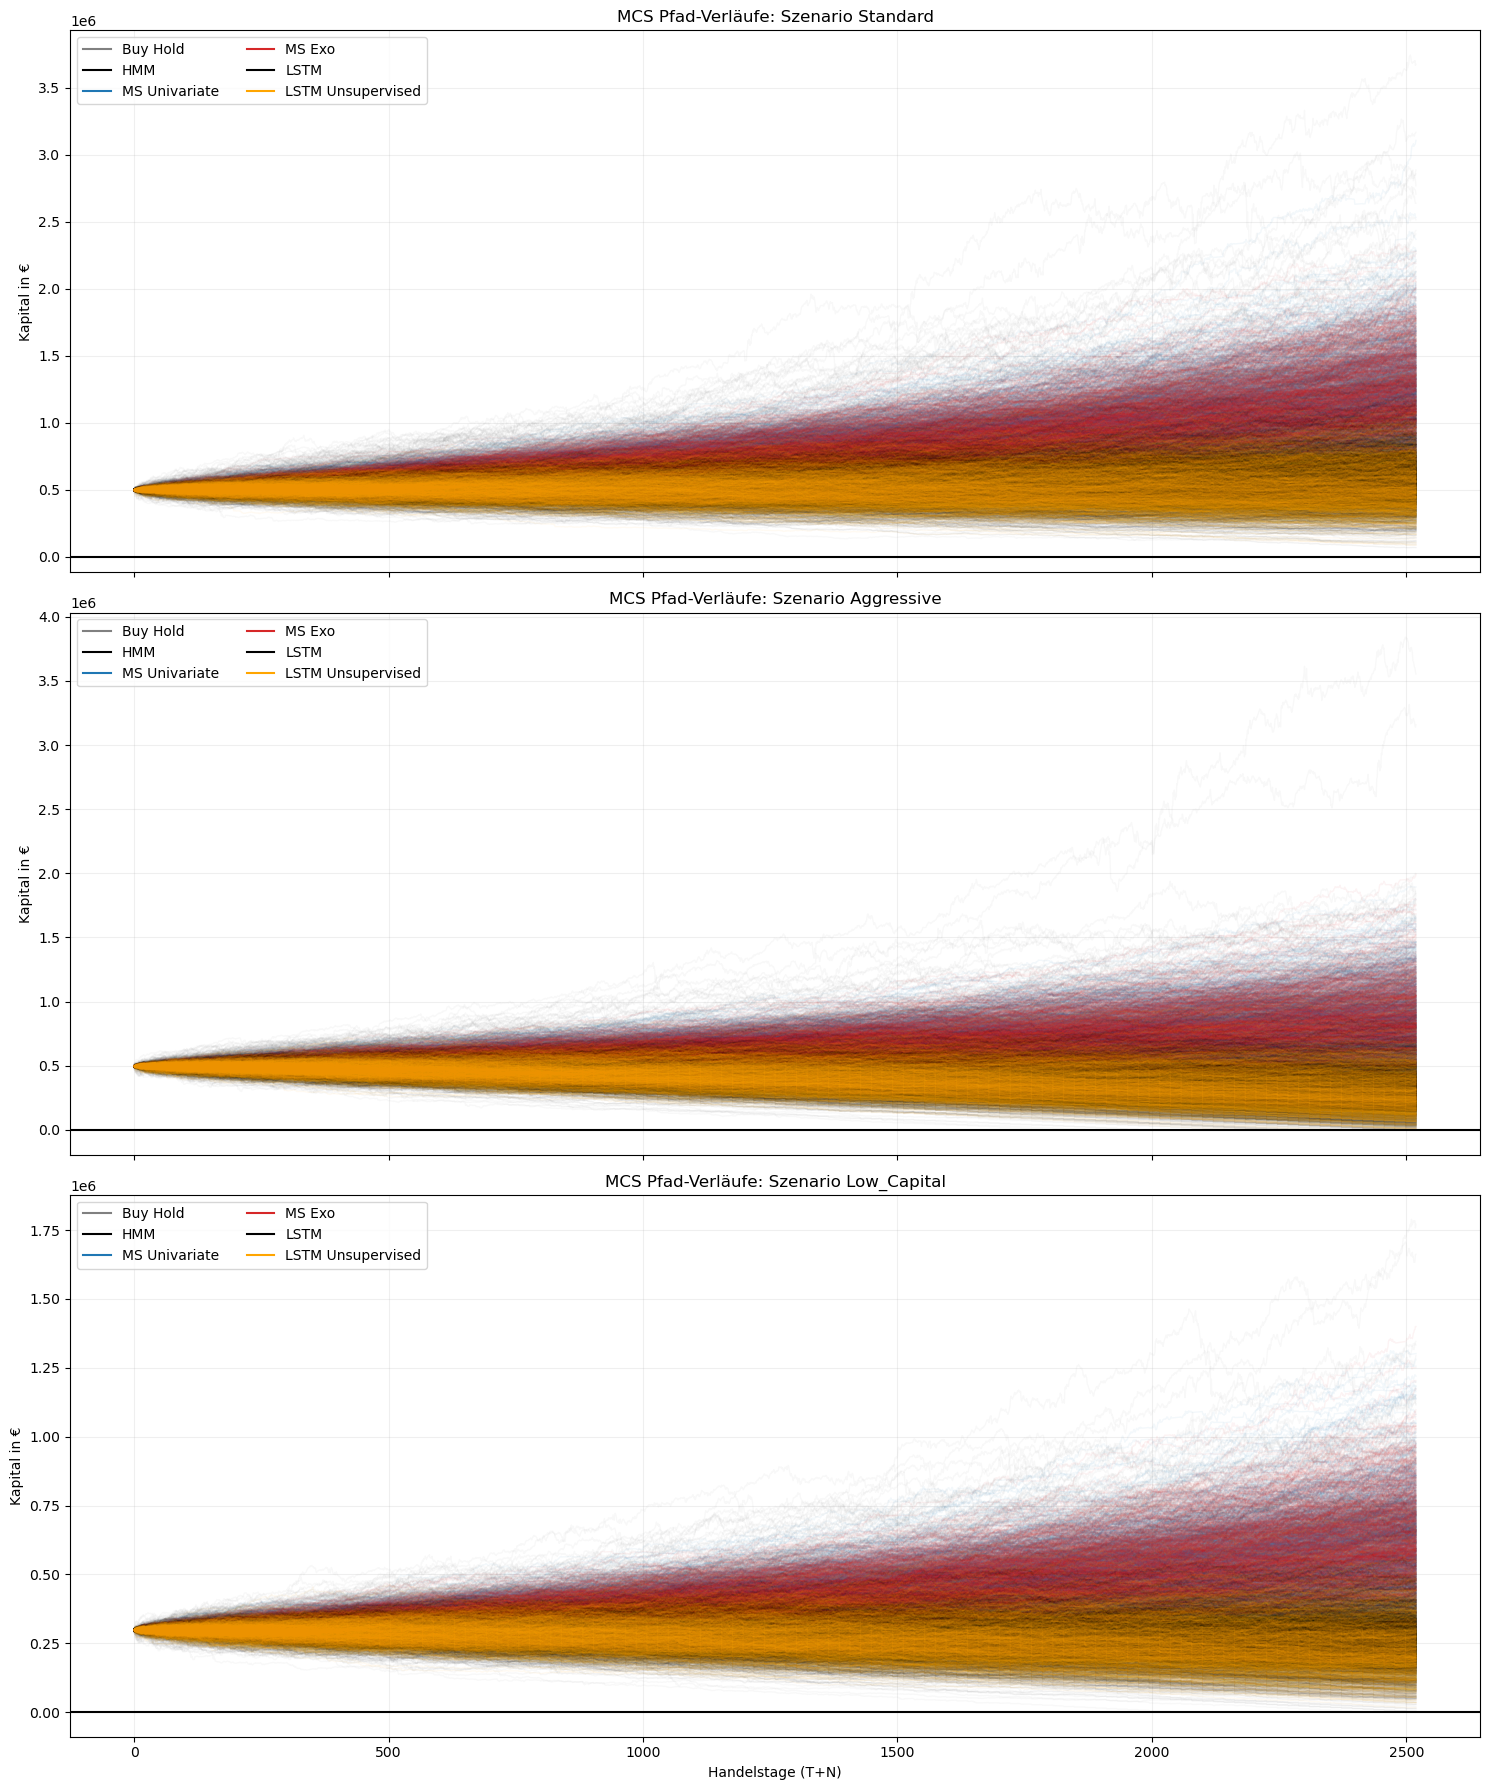

Berechne Quantile für Standard...


Berechne Quantile für Aggressive...


Berechne Quantile für Low_Capital...


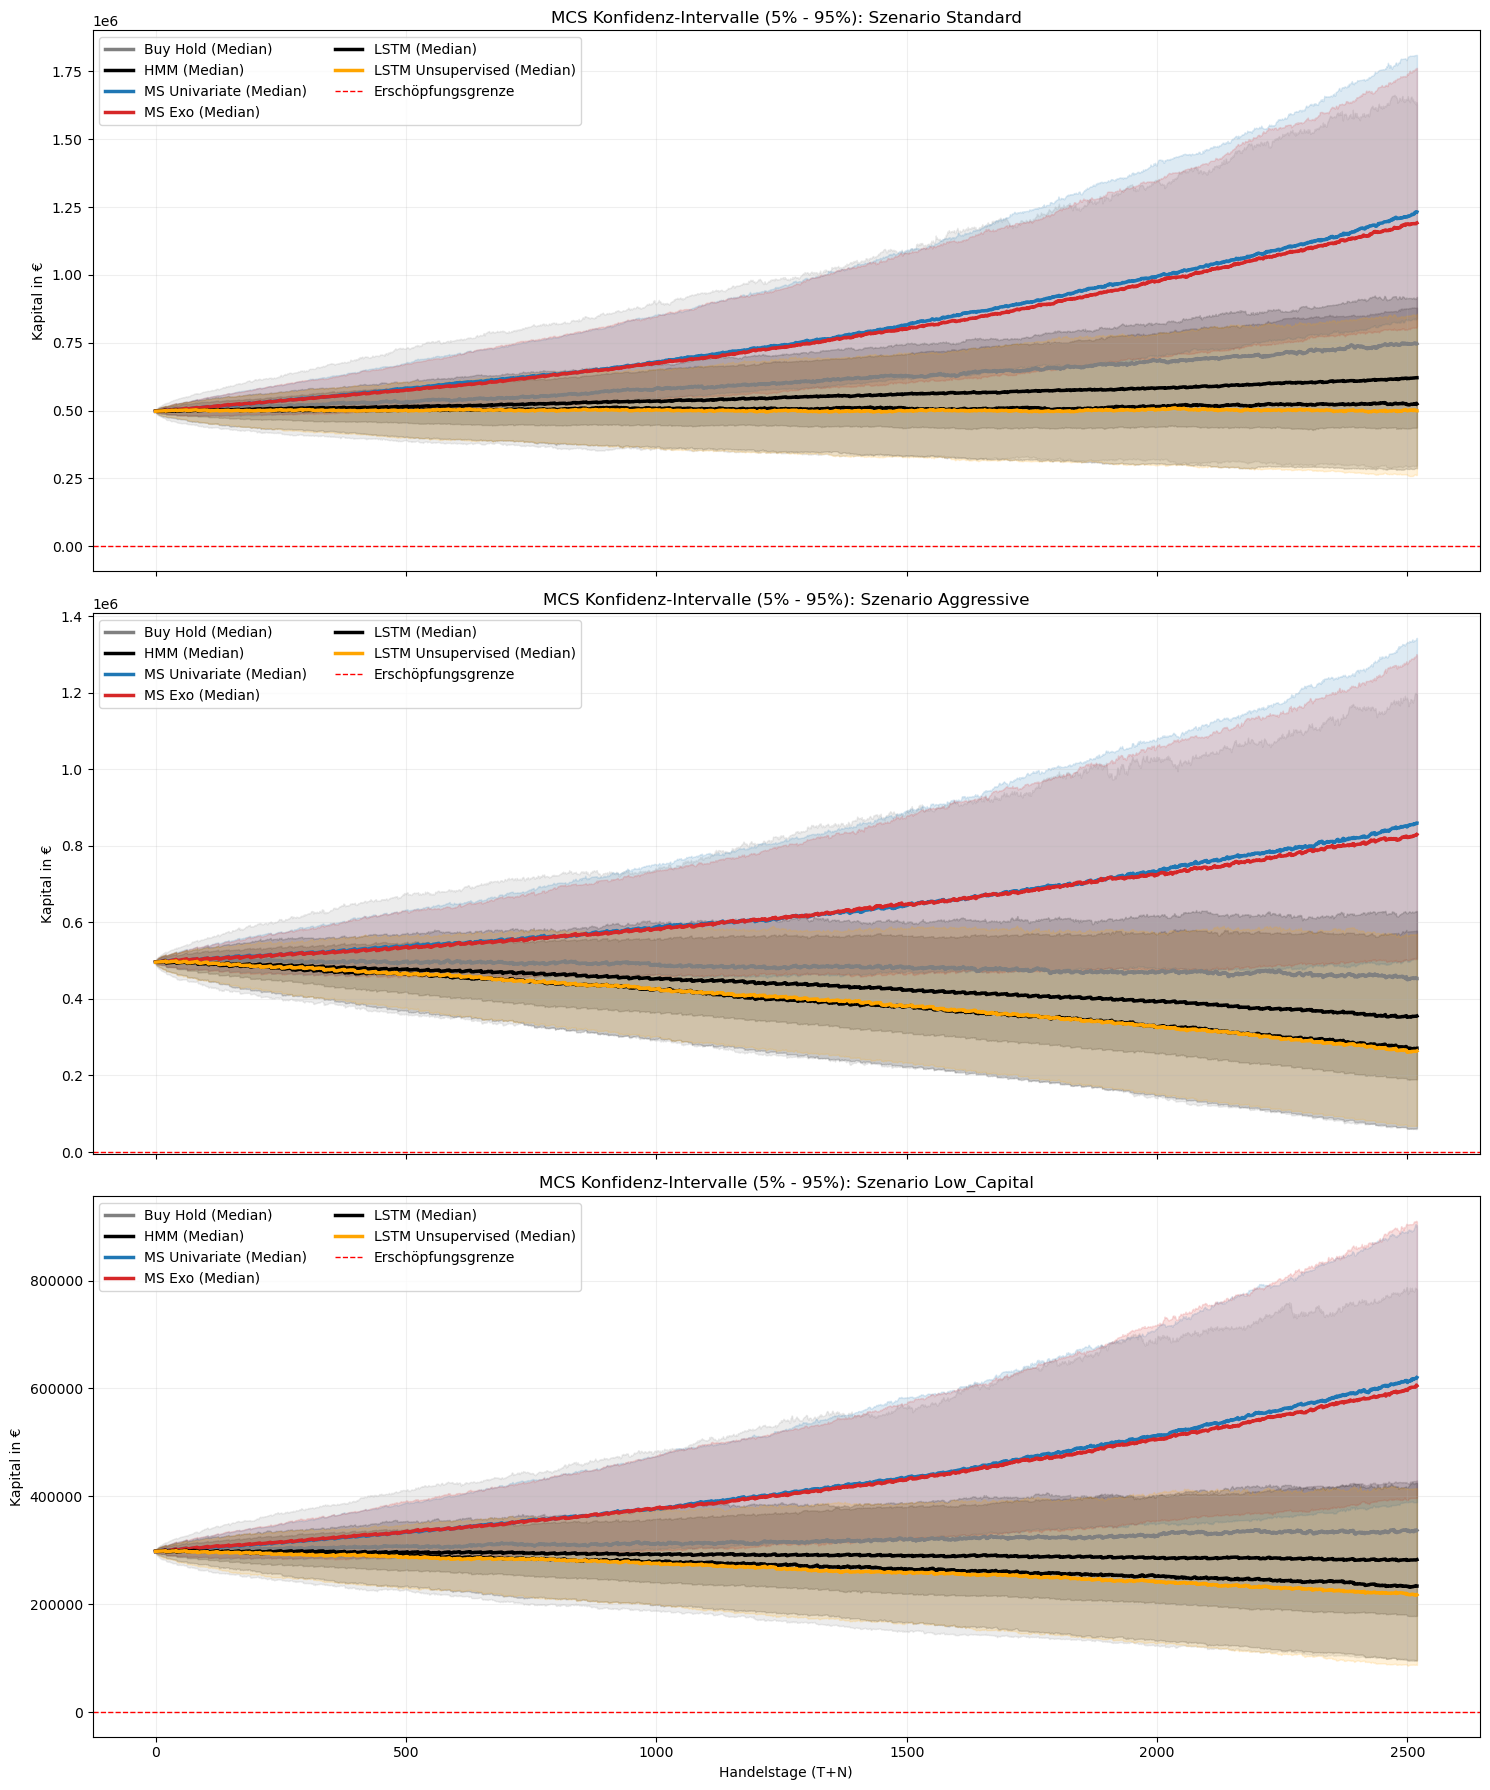

In [3]:
# --- 06_MCS: Block-Bootstrap Robustness-Check ---

import matplotlib.pyplot as plt
import os

# Parameter definieren
N_SIMULATIONS = 1000            # Anzahl der Pfade pro Strategie/Szenario
BLOCK_SIZE = 20                 # Block-Länge für Bootstrap (ca. 1 Monat)
SIM_YEARS = 10                  # Simulationshorizont
TRADING_DAYS = 252
TOTAL_DAYS = SIM_YEARS * TRADING_DAYS

# Definition der Szenarien
scenarios = {
    "Standard": {"start": 500000.0, "withdrawal": 2500.0, "fee": 0.001},
    "Aggressive": {"start": 500000.0, "withdrawal": 4000.0, "fee": 0.001},
    "Low_Capital": {"start": 300000.0, "withdrawal": 2000.0, "fee": 0.002}
}

# Tägliche Netto-Renditen der Strategien berechnen
daily_rets = backtesting_results.pct_change().dropna()

# Prüfen, ob Renditen vorhanden sind ---
if daily_rets.empty:
    raise ValueError("daily_rets ist leer. Prüfe die Datenquelle backtesting_results.")

# --- DYNAMISIERUNG: Automatische Zuordnung von Strategie zu Signal ---
def find_matching_signal_col(strategy_name, test_df_columns):
    if strategy_name == 'Buy_Hold':
        return None
    if f"{strategy_name}_Signal" in test_df_columns:
        return f"{strategy_name}_Signal"
    root_name = strategy_name.split('_')[0]
    potential_cols = [c for c in test_df_columns if root_name in c and "Signal" in c]
    if len(potential_cols) == 1:
        return potential_cols[0]
    for c in potential_cols:
        if strategy_name[:5] in c:
            return c
    return None

# Simulations-Loop
all_mc_summaries = []
mcs_paths_collector = {} # Dictionary zum Sammeln ALLER Pfade

for sc_name, params in scenarios.items():
    print(f"Starte Monte Carlo Simulation für Szenario: {sc_name}")
    mc_results_scenario = {}
    
    for strategy in daily_rets.columns:
        final_capitals = []
        sig_col = find_matching_signal_col(strategy, test_df.columns)
        
        for s in range(N_SIMULATIONS):
            # --- Paired Block Bootstrap ---
            sim_rets = []
            sim_sigs = []
            
            while len(sim_rets) < TOTAL_DAYS:
                start_idx = np.random.randint(0, len(daily_rets) - BLOCK_SIZE)
                sim_rets.extend(daily_rets[strategy].iloc[start_idx : start_idx + BLOCK_SIZE].values)
                if sig_col:
                    sim_sigs.extend(test_df[sig_col].iloc[start_idx : start_idx + BLOCK_SIZE].values)
                else:
                    sim_sigs.extend([0] * BLOCK_SIZE)

            sim_rets = np.array(sim_rets[:TOTAL_DAYS])
            sim_sigs = np.array(sim_sigs[:TOTAL_DAYS])
            
            # --- Entnahme-Simulation ---
            cap = params["start"]
            capital_history = [] 
            
            for i in range(TOTAL_DAYS):
                cap *= (1 + sim_rets[i])
                
                if i % 21 == 0:
                    withdrawal_amt = params["withdrawal"]
                    if sim_sigs[i] == 0:
                        withdrawal_amt += (params["withdrawal"] * params["fee"])
                    cap -= withdrawal_amt
                    
                # Kapitalverlauf sichern und Zero-Padding bei Erschöpfung ---
                if cap <= 0:
                    cap = 0.0
                    capital_history.append(0.0)
                    remaining_days = TOTAL_DAYS - len(capital_history)
                    capital_history.extend([0.0] * remaining_days)
                    break
                else:
                    capital_history.append(cap)
            
            final_capitals.append(cap)
            
            # Pfad im Collector speichern
            path_id = f"{sc_name}_{strategy}_path_{s:03d}"
            mcs_paths_collector[path_id] = capital_history
        
        mc_results_scenario[strategy] = final_capitals
        
        # Statistik berechnen
        # Sicherstellen, dass final_capitals nicht leer ist
        if len(final_capitals) > 0:
            ruin_prob = np.mean(np.array(final_capitals) <= 0)
            median_wealth = np.median(final_capitals)
            
            all_mc_summaries.append({
                'Szenario': sc_name,
                'Strategie': strategy.replace('_', ' '),
                'Ruin-Wahrscheinlichkeit': f"{ruin_prob:.2%}",
                'Median Endkapital': f"{median_wealth:,.2f} €"
            })

    # Visualisierung pro Szenario
    if mc_results_scenario:
        plt.figure(figsize=(12, 6))
        plt.boxplot(mc_results_scenario.values(), 
                    labels=[s.replace('_', ' ') for s in mc_results_scenario.keys()])
        plt.title(f"MCS {sc_name}: Verteilung des Endkapitals (Start: {params['start']}€)")
        plt.ylabel(f"Endkapital nach {SIM_YEARS} Jahren in €")
        plt.axhline(y=0, color='red', linestyle='--')
        plt.grid(axis='y', alpha=0.3)
        plt.savefig(f'../assets/mcs_boxplot_{sc_name.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

# Ergebnisse zusammenführen und als Markdown-Tabelle speichern
if all_mc_summaries:
    mc_multi_summary = pd.DataFrame(all_mc_summaries).set_index(['Szenario', 'Strategie'])
    mc_multi_summary.to_markdown('../assets/mcs_summary.md')
    display(mc_multi_summary)

print("Alle Monte Carlo Simulationen abgeschlossen.")

mcs_results = pd.DataFrame(mcs_paths_collector)
print(mcs_results)

#---

# Liste der Szenarien und Strategien extrahieren
scenarios_list = ["Standard", "Aggressive", "Low_Capital"]
strategies = backtesting_results.columns # Dynamisch von den Backtest-Ergebnissen

color_map = {
    'Buy_Hold': 'gray',
    'MS_Univariate': 'tab:blue',
    'MS_Exo': 'tab:red',
    'HMM_Based': 'purple',
    'LSTM_Regime': 'green',
    'LSTM_Unsupervised': 'orange'
}

# --- Plot: MCS Pfad-Verläufe ---
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

for ax, sc_name in zip(axes, scenarios_list):
    print(f"Plotte Pfad-Verläufe für {sc_name}...")
    
    for strat in strategies:
        # Filter alle Pfade für dieses Szenario und diese Strategie
        # Name-Format: Szenario_Strategie_path_XXX
        prefix = f"{sc_name}_{strat}_path_"
        strat_paths = mcs_results.filter(like=prefix)
        
        # Optional: Wir plotten 50 zufällige Pfade, um die Performance nicht zu sprengen
        #sample_paths = strat_paths.sample(n=50, axis=1, random_state=42)
        sample_paths = strat_paths
        
        color = color_map.get(strat, 'black')
        alpha = 0.05 # Sehr transparent für den "Wolken"-Effekt
        
        ax.plot(sample_paths, color=color, alpha=alpha, linewidth=1)
        # Ein dickerer Dummy-Plot für die Legende
        ax.plot([], [], color=color, label=strat.replace('_', ' '))

    ax.set_title(f"MCS Pfad-Verläufe: Szenario {sc_name}")
    ax.set_ylabel("Kapital in €")
    ax.axhline(y=0, color='black', linewidth=1.5)
    ax.grid(alpha=0.2)
    ax.legend(loc='upper left', ncol=2)

plt.xlabel("Handelstage (T+N)")
plt.tight_layout()
plt.savefig('../assets/mcs_paths.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot: MCS Quantils-Verteilung ---
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

for ax, sc_name in zip(axes, scenarios_list):
    print(f"Berechne Quantile für {sc_name}...")
    
    for strat in strategies:
        prefix = f"{sc_name}_{strat}_path_"
        strat_paths = mcs_results.filter(like=prefix)
        
        # Quantile berechnen (über alle Pfade hinweg pro Zeitschritt)
        upper_95 = strat_paths.quantile(0.95, axis=1)
        lower_05 = strat_paths.quantile(0.05, axis=1)
        median_50 = strat_paths.median(axis=1)
        
        color = color_map.get(strat, 'black')
        
        # Fläche zwischen 5% und 95% füllen
        ax.fill_between(range(TOTAL_DAYS), lower_05, upper_95, color=color, alpha=0.15)
        # Median plotten
        ax.plot(median_50, color=color, linewidth=2.5, label=f"{strat.replace('_', ' ')} (Median)")

    ax.set_title(f"MCS Konfidenz-Intervalle (5% - 95%): Szenario {sc_name}")
    ax.set_ylabel("Kapital in €")
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label="Erschöpfungsgrenze")
    ax.grid(alpha=0.2)
    ax.legend(loc='upper left', ncol=2)

plt.xlabel("Handelstage (T+N)")
plt.tight_layout()
plt.savefig('../assets/mcs_quantiles.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
output_path = "../data/05_mcs_data.parquet"

# Speichern als Parquet
mcs_results.to_parquet(output_path)

print(f"MCS-Dataframe erfolgreich unter {output_path} gespeichert.")

MCS-Dataframe erfolgreich unter ../data/05_mcs_data.parquet gespeichert.
